# Using PyTorch to build, train, and test convolutional neural networks

## Agenda
*   Basic operations
  *    Convolution
  *    Activation
  *    Pooling
  *    Batch normalization
  *    Skip connection
  *    Linear
  *    Dropout
*   Loading and splitting a dataset  
*   Building a convolutional neural network
*   Defining loss function and optimizer
*   Training and testing
*   Saving and loading the model

anotacoes:
1- eu posso salvar em dicionarios mas ai preciso passar a arquitetura dos dados
2-

## Basic operations

PyTorch has a module called `nn` that provides a lot of useful tools to build neural networks. This module defines most commonly used operations, such as convolution, pooling and activation. We will see how to use some of these operations using module `nn`:

*   Convolution
*   Activation
*   Pooling
*   Batch normalization
*   Skip connection
*   Linear transformation (dense layer)
*   Dropout

In [ ]:
#import module nn
import torch
from torch import nn as nn

### Convolution

You must provide the number of input channels, the number of output channels (i.e., number of kernels), and the kernel sizes. To preserve image dimensions, you must provide the padding size.

CLASS torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)

In [ ]:
#it defines a convolution with 3 kernels of sizes 5 x 3 #temos 3 filtros aqui
#podemos zerar os cantos do quadrado/retangulo para fazer algo circular mas isso
# vai custar caro porque os filtros vao ser maiores, se for algo 3x3 sem problemas mas o problema e quando aumenta muito a matrix
# ai alterariamos o filtro que ele treinou e ai vamos piorar a rede
# testar diferentes paddings, por exmeplo com 0/0 a saida fica 6x6
conv = nn.Conv2d(in_channels=2, out_channels=3, kernel_size=(5, 3), padding=(2,1))

The weights are stored in a tensor $K_{N, M, P, Q}$, such that
$N$ is the number of kernels, $M$ is the number of input channels, $P$ and $Q$ are the input dimensions (height, width).



In [ ]:
print(conv.weight.data.shape)
#quando comecar o treinamento ai ele vai fazer o foward, bias e a posicao do plano

torch.Size([3, 2, 5, 3])


The input is a tensor $I_{B, M, P, Q}$, such that $B$ is the batch size, $M$ is the number of channels, and $P$ and $Q$ are the input dimensions (height, width).

In [ ]:
#creating a random input
x = torch.rand(1, 2, 10, 8) #se colocar o padding igual a 0 10 perde 4 (2 de cada lado)
# e 8 perde 2, 1 de cada lado
print("x = ", x)
print(x.size())

x =  tensor([[[[0.0735, 0.0364, 0.0207, 0.9455, 0.9865, 0.6880, 0.4847, 0.2027],
          [0.1339, 0.5649, 0.9840, 0.0237, 0.9670, 0.0441, 0.6236, 0.2926],
          [0.2464, 0.9473, 0.7488, 0.8156, 0.3310, 0.5033, 0.0628, 0.3278],
          [0.1646, 0.1481, 0.2593, 0.8350, 0.8660, 0.5168, 0.3065, 0.5952],
          [0.6859, 0.3199, 0.3006, 0.0993, 0.0648, 0.8577, 0.5722, 0.7481],
          [0.4518, 0.0884, 0.5486, 0.7133, 0.8976, 0.4444, 0.7822, 0.6499],
          [0.7681, 0.4037, 0.6399, 0.3565, 0.7501, 0.4305, 0.1723, 0.2512],
          [0.7157, 0.5363, 0.4612, 0.5874, 0.7771, 0.1687, 0.2327, 0.2076],
          [0.7431, 0.5805, 0.4259, 0.6414, 0.6515, 0.0040, 0.3036, 0.5028],
          [0.5492, 0.9935, 0.1715, 0.5382, 0.8110, 0.0276, 0.3278, 0.7595]],

         [[0.0479, 0.0658, 0.0630, 0.8474, 0.2417, 0.6645, 0.4949, 0.7070],
          [0.9945, 0.1206, 0.6349, 0.9526, 0.1195, 0.3384, 0.0655, 0.2552],
          [0.3421, 0.1020, 0.5594, 0.3156, 0.7418, 0.3066, 0.4148, 0.6616],
     

In [ ]:
#Convolving x with the three kernels that have already been randomly initialized
y_conv = conv(x)
print("y_conv = ", y_conv)
print(y_conv.shape)

y_conv =  tensor([[[[-0.1909, -0.1091, -0.3744, -0.4139, -0.2385, -0.0228, -0.1851,
            0.0732],
          [-0.4493, -0.3237, -0.3711, -0.1821, -0.1370,  0.1021,  0.0832,
            0.1678],
          [-0.2999, -0.1283, -0.0951, -0.2443, -0.2830, -0.1896, -0.2458,
           -0.1362],
          [-0.4515, -0.4601, -0.2400, -0.5169, -0.3867, -0.4922, -0.1929,
           -0.0696],
          [-0.5895, -0.1714, -0.3354, -0.3490, -0.1635, -0.3665, -0.0636,
            0.1501],
          [-0.4322,  0.0580, -0.3426, -0.5457, -0.5423, -0.1663, -0.3069,
            0.1613],
          [-0.4817, -0.1652, -0.3485, -0.3743, -0.3376,  0.0169, -0.2076,
            0.1638],
          [-0.6338, -0.1371, -0.3120, -0.4455, -0.1617,  0.0889, -0.2609,
           -0.0475],
          [-0.5298, -0.1210, -0.0646, -0.3856, -0.0144,  0.1797, -0.3860,
           -0.0401],
          [-0.2788, -0.2954, -0.2495, -0.2936, -0.0913, -0.0018, -0.0253,
           -0.0633]],

         [[-0.2796, -0.2286, -0.1417, 

We can also set the kernel weights as we want.

In [ ]:
#initializing weights and biases
conv.weight.data = torch.rand(3, 2, 5, 3, requires_grad=True) - 0.5
conv.bias.data   = torch.rand(3, requires_grad=True) - 0.5

In [ ]:
#Convolving x with our new kernel bank of three kernels
y_conv = conv(x)
print("y_conv = ", y_conv)
print(y_conv.shape)

y_conv =  tensor([[[[ 0.5008,  1.1873,  1.2543,  0.2469, -0.0355, -0.2258,  0.1286,
           -0.1148],
          [ 0.0983,  0.6344,  1.1308,  0.8394,  1.2828,  1.0688,  0.9334,
            0.0133],
          [ 0.6442,  0.8310,  0.9354,  1.7448,  1.2141,  1.7952,  1.4228,
            0.3932],
          [ 1.6361,  1.4186,  1.8151, -0.2205,  0.5733,  0.4934,  1.1996,
            0.2703],
          [ 0.2997,  0.8854,  1.4562,  1.9383,  1.9602,  1.3651,  0.7075,
            0.2490],
          [ 1.3137,  1.1079,  0.7213,  0.6018,  0.7470,  1.1316,  0.2958,
           -0.1940],
          [ 1.2730,  0.5317,  0.8047,  0.7234,  0.7075,  1.9661,  0.7138,
            0.5647],
          [ 1.0096,  0.9493,  1.6620,  1.0526,  1.2669,  1.5676,  0.7642,
            0.0720],
          [ 0.9479,  0.9612,  1.2553,  0.7237,  1.3901,  0.7969, -0.2111,
           -0.3576],
          [ 0.6303, -0.3458, -0.5701,  0.0940, -0.2605, -0.5094, -0.2877,
           -0.9034]],

         [[ 0.0444,  1.0879,  0.5465, 


### Activation

Now we define a ReLU activation function.

CLASS torch.nn.ReLU(inplace=False)

In [ ]:
#defining relu function
# testar interpolacao no lugar da deconvolucao
# no momento que eu coloco a interpolacao eu deixo de aprender a camada
relu = nn.ReLU()

In [ ]:
#applying the relu function to output of a convolution
y_relu = relu(y_conv) #relu zera o que ta negativo
print("y_relu = ",y_relu)

y_relu =  tensor([[[[0.5008, 1.1873, 1.2543, 0.2469, 0.0000, 0.0000, 0.1286, 0.0000],
          [0.0983, 0.6344, 1.1308, 0.8394, 1.2828, 1.0688, 0.9334, 0.0133],
          [0.6442, 0.8310, 0.9354, 1.7448, 1.2141, 1.7952, 1.4228, 0.3932],
          [1.6361, 1.4186, 1.8151, 0.0000, 0.5733, 0.4934, 1.1996, 0.2703],
          [0.2997, 0.8854, 1.4562, 1.9383, 1.9602, 1.3651, 0.7075, 0.2490],
          [1.3137, 1.1079, 0.7213, 0.6018, 0.7470, 1.1316, 0.2958, 0.0000],
          [1.2730, 0.5317, 0.8047, 0.7234, 0.7075, 1.9661, 0.7138, 0.5647],
          [1.0096, 0.9493, 1.6620, 1.0526, 1.2669, 1.5676, 0.7642, 0.0720],
          [0.9479, 0.9612, 1.2553, 0.7237, 1.3901, 0.7969, 0.0000, 0.0000],
          [0.6303, 0.0000, 0.0000, 0.0940, 0.0000, 0.0000, 0.0000, 0.0000]],

         [[0.0444, 1.0879, 0.5465, 0.8923, 0.4315, 0.5466, 0.3853, 0.0000],
          [0.7753, 0.1129, 1.0075, 1.6445, 0.7967, 1.7291, 0.6083, 0.3502],
          [0.6785, 1.1706, 2.0538, 1.4361, 1.7003, 1.1206, 1.6295, 0.4888],


### Pooling

We may define now max pooling. Note that strides greater than 1 will reduce the input size.

CLASS torch.nn.MaxPool2d(kernel_size, stride=None, padding=0, dilation=1, return_indices=False, ceil_mode=False)

In [ ]:
pool = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
#com stride 1 nao perde nada, mas o 2 diminui o tamanho da imagem, isso faz perder resolucao espacial
#

In [ ]:
#applying max pooling to output of ReLu
y_pool = pool(y_relu)
print("y_pool = ", y_pool)
print(y_pool.shape)

y_pool =  tensor([[[[1.1873, 1.2543, 1.2543, 1.2828, 1.2828, 1.2828, 1.0688, 0.9334],
          [1.1873, 1.2543, 1.7448, 1.7448, 1.7952, 1.7952, 1.7952, 1.4228],
          [1.6361, 1.8151, 1.8151, 1.8151, 1.7952, 1.7952, 1.7952, 1.4228],
          [1.6361, 1.8151, 1.9383, 1.9602, 1.9602, 1.9602, 1.7952, 1.4228],
          [1.6361, 1.8151, 1.9383, 1.9602, 1.9602, 1.9602, 1.3651, 1.1996],
          [1.3137, 1.4562, 1.9383, 1.9602, 1.9661, 1.9661, 1.9661, 0.7138],
          [1.3137, 1.6620, 1.6620, 1.6620, 1.9661, 1.9661, 1.9661, 0.7642],
          [1.2730, 1.6620, 1.6620, 1.6620, 1.9661, 1.9661, 1.9661, 0.7642],
          [1.0096, 1.6620, 1.6620, 1.6620, 1.5676, 1.5676, 1.5676, 0.7642],
          [0.9612, 1.2553, 1.2553, 1.3901, 1.3901, 1.3901, 0.7969, 0.0000]],

         [[1.0879, 1.0879, 1.6445, 1.6445, 1.7291, 1.7291, 1.7291, 0.6083],
          [1.1706, 2.0538, 2.0538, 2.0538, 1.7291, 1.7291, 1.7291, 1.6295],
          [1.6736, 2.0538, 2.0538, 2.0538, 2.0407, 2.0407, 2.0407, 1.6295],


### Batch normalization

Now we may define batch normalization to normalize batches in the following way $$y = \frac{x - \mathbb{E}[x]}{\sqrt{\mathrm{Var}[x]}}\gamma + \beta.$$ You must indicate the number of input channels.


CLASS torch.nn.BatchNorm2d(num_features, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, device=None, dtype=None)

In [ ]:
#defining batch normalization layer: affine=False indicates without learnable parameters.
#gama e beta e os parametros que desfazem o bath normalization, se eu disse que afine é false gama =1 e beta = 0
norm = nn.BatchNorm2d(num_features=3, affine=False)

In [ ]:
#applying batch normalization
y_norm = norm(y_pool)
print("y_norm = ", y_norm)

y_norm =  tensor([[[[-0.9099, -0.7391, -0.7391, -0.6666, -0.6666, -0.6666, -1.2116,
           -1.5565],
          [-0.9099, -0.7391,  0.5100,  0.5100,  0.6383,  0.6383,  0.6383,
           -0.3100],
          [ 0.2332,  0.6889,  0.6889,  0.6889,  0.6383,  0.6383,  0.6383,
           -0.3100],
          [ 0.2332,  0.6889,  1.0027,  1.0584,  1.0584,  1.0584,  0.6383,
           -0.3100],
          [ 0.2332,  0.6889,  1.0027,  1.0584,  1.0584,  1.0584, -0.4570,
           -0.8784],
          [-0.5880, -0.2249,  1.0027,  1.0584,  1.0735,  1.0735,  1.0735,
           -2.1157],
          [-0.5880,  0.2991,  0.2991,  0.2991,  1.0735,  1.0735,  1.0735,
           -1.9873],
          [-0.6915,  0.2991,  0.2991,  0.2991,  1.0735,  1.0735,  1.0735,
           -1.9873],
          [-1.3624,  0.2991,  0.2991,  0.2991,  0.0586,  0.0586,  0.0586,
           -1.9873],
          [-1.4857, -0.7365, -0.7365, -0.3933, -0.3933, -0.3933, -1.9039,
           -3.9334]],

         [[-1.8566, -1.8566, -0.2631, 

### Skip connection

To skip layers without passing through previous layers, we may concatenate or add the output of two layers. Concatenation increases the number of channels, while addition (as in residual connections) keeps them the same. Here we show concatenation along the channel axis.

torch.cat(tensors, dim=0, *, out=None) → Tensor

In [ ]:
#concatenating tensors
#so podemos somar coisas de mesmo dominio, mas podemos ter canais diferentes (concatenacao)
concat = torch.cat((x, y_relu), dim=1)
print("concat = ", concat)
print(concat.shape)

concat =  tensor([[[[0.0735, 0.0364, 0.0207, 0.9455, 0.9865, 0.6880, 0.4847, 0.2027],
          [0.1339, 0.5649, 0.9840, 0.0237, 0.9670, 0.0441, 0.6236, 0.2926],
          [0.2464, 0.9473, 0.7488, 0.8156, 0.3310, 0.5033, 0.0628, 0.3278],
          [0.1646, 0.1481, 0.2593, 0.8350, 0.8660, 0.5168, 0.3065, 0.5952],
          [0.6859, 0.3199, 0.3006, 0.0993, 0.0648, 0.8577, 0.5722, 0.7481],
          [0.4518, 0.0884, 0.5486, 0.7133, 0.8976, 0.4444, 0.7822, 0.6499],
          [0.7681, 0.4037, 0.6399, 0.3565, 0.7501, 0.4305, 0.1723, 0.2512],
          [0.7157, 0.5363, 0.4612, 0.5874, 0.7771, 0.1687, 0.2327, 0.2076],
          [0.7431, 0.5805, 0.4259, 0.6414, 0.6515, 0.0040, 0.3036, 0.5028],
          [0.5492, 0.9935, 0.1715, 0.5382, 0.8110, 0.0276, 0.3278, 0.7595]],

         [[0.0479, 0.0658, 0.0630, 0.8474, 0.2417, 0.6645, 0.4949, 0.7070],
          [0.9945, 0.1206, 0.6349, 0.9526, 0.1195, 0.3384, 0.0655, 0.2552],
          [0.3421, 0.1020, 0.5594, 0.3156, 0.7418, 0.3066, 0.4148, 0.6616],


### Linear

Dense layers can be implemented by flattening output activations followed by a linear transformation. We must indicate the input and output sizes.

torch.flatten(input, start_dim=0, end_dim=-1) → Tensor

CLASS torch.nn.Linear(in_features, out_features, bias=True, device=None, dtype=None)

In [ ]:
#transforming it into a 2D tensor
y_flatten = y_pool.flatten(start_dim=1)
print(y_flatten.shape)

torch.Size([1, 240])


In [ ]:
#defining the linear layer
# fazendo uma camada densa que eu peguei, cada amostra tem 240 cada valores, temos 2 neuronios e 240pesos
#fazendo uma reducao Rˆ240 para Rˆ2, temos 240 e chegamos em 2, é um exemplo de como entender as funcoes isoladamente
#quando estivermos fazendo a rede vamos diminuindo,
# mas precisamos saber da ultima camada, se o nosso problema ter 10 classes a ultima camada densa tem que ter 10 tambem
#a convolucao desmembra padroes, a ativacao apaga os falso positivos que não sao padroes da classe
#formados pelos pixels da camada de extracao
#projecao linear
#geralmente funciona assim a gente treina com back propagation e vemos onde converge
#tem que ter um mecanismo pra ir treinando as camadas e chegar
#numa arquitetura menor que treinando com o back propagation tem um arquiterutura maior
#e ai fica testando otimizacao busca genetica ou grid search geralmente e feito assim mas o professo propoe entender o que é cada coisa
linear = nn.Linear(in_features=240, out_features=2, bias=True)

In [ ]:
#applying linear the transformation
y_linear = linear(y_flatten)
print(y_linear)
print(y_linear.shape)

tensor([[-0.1082, -0.1796]], grad_fn=<AddmmBackward0>)
torch.Size([1, 2])


### Dropout

For regularization, we may also add a dropout layer to randomly disconsider elements of the input tensor (it sets zeroes) with probability p by following a Bernoulli distribution. The outputs are scaled by a factor $\frac{1}{1-p}$ during training.

CLASS torch.nn.Dropout(p=0.5, inplace=False)

In [ ]:
drop = nn.Dropout(0.5)
#fazemos dropout pra rede nao ficar presa no minimo local

In [ ]:
x = torch.randn((5,5))

In [ ]:
y = drop(x)

In [ ]:
print("Before dropout: ", x)

Before dropout:  tensor([[-0.4158,  1.3317, -0.2600,  0.5893, -0.4760],
        [-1.2831, -0.4294,  0.7274,  0.1123, -1.9375],
        [ 0.1075,  0.0748, -1.2693, -0.0202,  1.0592],
        [-0.8481, -0.2807,  1.4037,  0.6520,  0.7617],
        [ 1.0319,  1.7946,  0.9164,  0.4490,  0.9016]])


In [ ]:
print("After dropout", y)

After dropout tensor([[-0.8316,  2.6635, -0.5201,  0.0000, -0.9520],
        [-2.5662, -0.0000,  1.4547,  0.2247, -3.8749],
        [ 0.0000,  0.1497, -0.0000, -0.0405,  0.0000],
        [-0.0000, -0.0000,  0.0000,  1.3039,  1.5234],
        [ 2.0639,  0.0000,  1.8327,  0.8981,  0.0000]])


# Building a CNN for fashion mnist

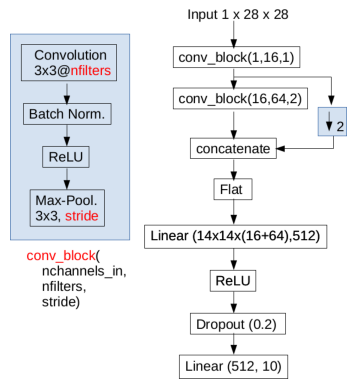

In [ ]:
import matplotlib.pyplot as plt

#bloc1 - strider 1, e no bloco 2 o strider é 2
#bloco 2 -16 filtros
#bloco 3, sai 16 e entra 64
#pra eu concatenar a saida do bloco 1 pro bloco 2 eu tenho que fazer elas terem a mesma dimensao
#ai faco o flat pra jogar na camada densa
#ai depois da camada densa entro o ultima camada linear
#512 na camda de decisao
#saida 10 figurinhas
fig = plt.imread('./figs/fmnist.png')
plt.imshow(fig)
plt.axis("off")
plt.show()

#CONCATENATE E FLAT DEFINE NO FORWARD

### Loading the Dataset

In [ ]:
#import modules to manipulate data
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision import transforms
import torch.optim as optim

In [ ]:
#define transformations between brackets to apply on the dataset images. For instance, convert them into tensors.
transformations = transforms.Compose([transforms.ToTensor()])

#### You may load training and test images separately or

In [ ]:
#training_set = datasets.FashionMNIST(
#    root="./images",
#    train=True,
#    download=True,
#    transform=transformations
#)

#test_set = datasets.FashionMNIST(
#    root="./images",
#    train=False,
#    download=True,
#    transform=transformations
#)

#### you may download the training set and split it as you wish.

In [ ]:
data_set = datasets.FashionMNIST(
    root="./images",
    train=True,
    download=True,
    transform=transformations
) #gerando o tensor

In [ ]:
#divide the dataset randomly into train, valid, and test sets.
trainset, validset, testset = random_split(data_set, [40000, 10000, 10000])

### Visualizing training images

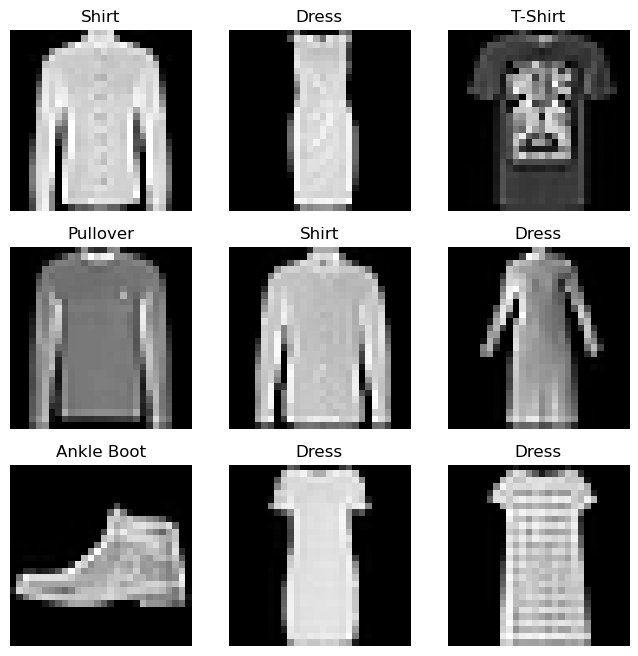

In [ ]:
#cada classe tem um label
#resolucao baixa 28x28
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(trainset), size=(1,)).item()
    img, label = trainset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### Defining Dataloaders

A dataloader divides a dataset into batches for iteration. Each iteration returns the next batch of train_features and train_labels (containing batch_size=64 features and labels, for instance). By specifying shuffle=True, after we iterate over all batches the dataset is shuffled (this is important to avoid overfitting when training a NN).

DataLoader(dataset, batch_size=1, shuffle=False, sampler=None,
           batch_sampler=None, num_workers=0, collate_fn=None,
           pin_memory=False, drop_last=False, timeout=0,
           worker_init_fn=None, *, prefetch_factor=2,
           persistent_workers=False)

In [ ]:
#defining dataloader that will generate batches with 64 images at random
trainload = DataLoader(trainset, batch_size=64, shuffle=True)
validload = DataLoader(validset, batch_size=64, shuffle=False)
testload  = DataLoader(testset, batch_size=64, shuffle=False)

Feature batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


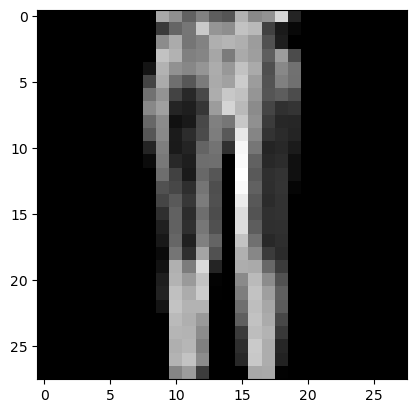

Label: 1 Object: Trouser


In [ ]:
# For instance, you can access a batch and display image and label of its first sample.

train_features, train_labels = next(iter(trainload)) # returns a batch
print("Feature batch shape: {}".format(train_features.shape)) # prints the shape of the features
print("Label batch shape: {}".format(train_labels.shape)) # prints the shape of the labels
img   = train_features[16].squeeze() # returns the first image
label = train_labels[16] # returns its label
plt.imshow(img, cmap="gray") # shows image and label
plt.show()
print("Label: {} Object: {}".format(label.item(), labels_map[label.item()]))

### Defining our CNN model

In [ ]:
import math

In [ ]:
# a convolutional block
def conv_block(nchannels_in, nchannels_out, stride_val):
    return nn.Sequential(
        #defining convolutional layer
        nn.Conv2d(in_channels=nchannels_in, out_channels=nchannels_out, kernel_size=(3, 3),
                  stride=1, padding=1, bias=False),
        #defining a batch normalization layer
        nn.BatchNorm2d(num_features=nchannels_out),
        #defining activation layer
        nn.ReLU(),
        #defining a pooling layer
        nn.MaxPool2d(kernel_size=(3, 3), stride=stride_val, padding=1)
    )

# Note that some operations, such as skip connection and downsampling, can be done in the forward method
class FMNISTNet(nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        #entra 1 sai 16 e stride 1
        #define the first conv_block
        self.conv1 = conv_block(1,16,1)

        #defining the second conv_block
        self.conv2 = conv_block(16,64,2)

        #defining classifier #MLP
        self.classifier = nn.Sequential(
            #defining linear layer
            nn.Linear(in_features=int((28*28*(16+64))/(2*2)), out_features=512, bias=True),
            #defining activation layer
            nn.ReLU(),
            # defining a dropout layer
            nn.Dropout(0.2),
            #defining linear layer as decision layer
            #num_classes = 10
            nn.Linear(512, num_classes) #Note that you do not need nn.Softmax in torch
        )

        #initialize weights
        # se eu nao fizer isso aqui vai usar o default (xavier)
        self._initialize_weights()

    # vai pegar em todas as imagens e rodar a mesma coisa, esse batch, o X vai ser um tensor (vetor de tensores) com 28 imagens
    def forward(self, x):
        #extracts features
        x1      = self.conv1(x) #saida da camada 1
        x2      = self.conv2(x1) #saida da camada 2, nao posso concatenar
        #ainda porque estao com dimensoes diferentes, ai faco a interpolacao abaixo pra conseguir concatenar
        #resizes x1 to have the same size of x2. See other operations in functional.
        x1      = torch.nn.functional.interpolate(x1, scale_factor=(0.5, 0.5), mode='nearest',
                                                  recompute_scale_factor=True) #16+64 somados
        #performs skip connection
        x       = torch.cat((x1, x2), dim=1) #ai do o flat no x e concateno

        #transforms outputs into a 2D tensor
        x = torch.flatten(x, start_dim=1)

        #classifies features
        y = self.classifier(x)

        return y

    # Same as Xavier: nn.init.xavier_normal_()
    def _initialize_weights(self):
        #for each submodule of our network
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                #get the number of elements in the layer weights
                n = m.kernel_size[0] * m.kernel_size[1] * m.in_channels

                #initialize layer weights with random values generated from a normal
                #distribution with mean = 0 and std = sqrt(2. / n))
                m.weight.data.normal_(mean=0, std=math.sqrt(2. / n))

                if m.bias is not None:
                    #initialize bias with 0
                    m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                #initialize layer weights with random values generated from a normal
                #distribution with mean = 0 and std = 1/100
                m.weight.data.normal_(mean=0, std=0.01)
                if m.bias is not None:
                #initialize bias with 0
                    m.bias.data.zero_()

### Defining a device and creating the model

In [ ]:
#is GPU available?
gpu = torch.cuda.is_available()

#defining device where to to the computation
device = torch.device(0) if gpu else torch.device('cpu')

In [ ]:
#creating the model to a dataset with 10 classes and moving it to the correct device
model = FMNISTNet(num_classes=10).to(device)

### Show the model architecture

In [ ]:
print(model)

FMNISTNet(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(3, 3), stride=1, padding=1, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(3, 3), stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=15680, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)


### Show the trainable parameters: weights and bias

In [ ]:
params = list(model.parameters())
print(len(params))
print(params[0][0]) # random weights of the first filter of the convolutional layer
print(params[1][0]) # the bias of that filter

10
tensor([[[ 0.0546,  1.0368,  0.9584],
         [ 0.1488, -0.3232,  0.1878],
         [ 0.4127,  0.3829,  0.2612]]], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor(1., device='cuda:0', grad_fn=<SelectBackward0>)


### Loss function

We use the cross entropy as loss function, which combines softmax and cross entropy.

CLASS torch.nn.CrossEntropyLoss(weight=None, size_average=None, ignore_index=-100, reduce=None, reduction='mean')

In [ ]:
# Create loss function once (not per batch)
ce_loss = nn.CrossEntropyLoss()

# comparar a predicao com o target (que é a loss) e fazer a entropia cruzada
def Criterion(preds, targets):
    loss        = ce_loss(preds, targets.long())
    pred_labels = torch.argmax(preds, dim=1)
    acc         = torch.sum(pred_labels == targets.data).item() / pred_labels.size(0) #verifico o label predito pela loss pra prever a accuraria
    return loss, acc

criterion = Criterion

# baixar o pacote metrics e ver a metrica "kappa" que ele penaliza, mas o aprendizado é pela loss, considerar na loss o "kappa"de alguma maneira

### Optimizer

PyTorch has many optimization algorithms. Here we are going to use the Stochastic Gradient Descent.

In [ ]:
#import module that defines the optimizer
import torch.optim as optim

To create a optimizer, we need to set a learning rate, a momentum, a weight_decay (L2 regularization).

CLASS torch.optim.SGD(params, lr=<required parameter>, momentum=0, dampening=0, weight_decay=0, nesterov=False)

In [ ]:
#defining optimizer
# variacoes do gradiente, ele escolheu o descendente
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.85, weight_decay=0.0001)

We can use a learning rate scheduler that can update the learning rate during training. Here we will use a scheduler that multiply the learning rate by a factor $\gamma$ at every $25$ epochs: e.g., lr=0.5, 0.05, 0.005...

CLASS torch.optim.lr_scheduler.StepLR(optimizer, step_size, gamma=0.1, last_epoch=-1, verbose=False)


In [ ]:
#defining learning rate scheduler
#learning scheduler para diminuir a loss
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.1)

### Defining training and validation/test functions

In [ ]:
#treinando o modelo por batch
def train_batch(model, data, optimizer, criterion, device):
    model.train()
    ims, targets = data
    ims     = ims.to(device)
    targets = targets.to(device)

    optimizer.zero_grad()          # 1. reset gradients
    preds      = model(ims)        # 2. forward pass
    loss, acc  = criterion(preds, targets)  # 3. compute loss
    loss.backward()                # 4. backward pass
    optimizer.step()               # 5. update weights
    return loss.item(), acc

@torch.no_grad()
def validate_batch(model, data, criterion, device):
    model.eval()
    ims, targets = data
    ims     = ims.to(device)
    targets = targets.to(device)
    preds      = model(ims)
    loss, acc  = criterion(preds, targets)
    return loss.item(), acc

### Training your model

In [ ]:
n_epochs = 40

# Track metrics
trn_losses, trn_accs = [], []
val_losses, val_accs = [], []

for epoch in range(n_epochs):
    # --- Training ---
    epoch_trn_loss, epoch_trn_acc, n_batches = 0, 0, 0
    for data in trainload:
        loss, acc = train_batch(model, data, optimizer, criterion, device)
        epoch_trn_loss += loss
        epoch_trn_acc  += acc
        n_batches += 1
    trn_losses.append(epoch_trn_loss / n_batches)
    trn_accs.append(epoch_trn_acc / n_batches)

    # --- Validation ---
    epoch_val_loss, epoch_val_acc, n_batches = 0, 0, 0
    for data in validload:
        loss, acc = validate_batch(model, data, criterion, device)
        epoch_val_loss += loss
        epoch_val_acc  += acc
        n_batches += 1
    val_losses.append(epoch_val_loss / n_batches)
    val_accs.append(epoch_val_acc / n_batches)

    # Step the learning rate scheduler
    lr_scheduler.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} — "
              f"Train loss: {trn_losses[-1]:.4f}, acc: {trn_accs[-1]:.4f} | "
              f"Val loss: {val_losses[-1]:.4f}, acc: {val_accs[-1]:.4f}")

        #esse exemplo ficou overfitado mas olhando pro teste a diff nao e tanta

Epoch  10/40 — Train loss: 0.1445, acc: 0.9445 | Val loss: 0.2656, acc: 0.9184
Epoch  20/40 — Train loss: 0.0498, acc: 0.9820 | Val loss: 0.2779, acc: 0.9219
Epoch  30/40 — Train loss: 0.0076, acc: 0.9985 | Val loss: 0.3057, acc: 0.9313
Epoch  40/40 — Train loss: 0.0054, acc: 0.9991 | Val loss: 0.3153, acc: 0.9321


### Plot the results

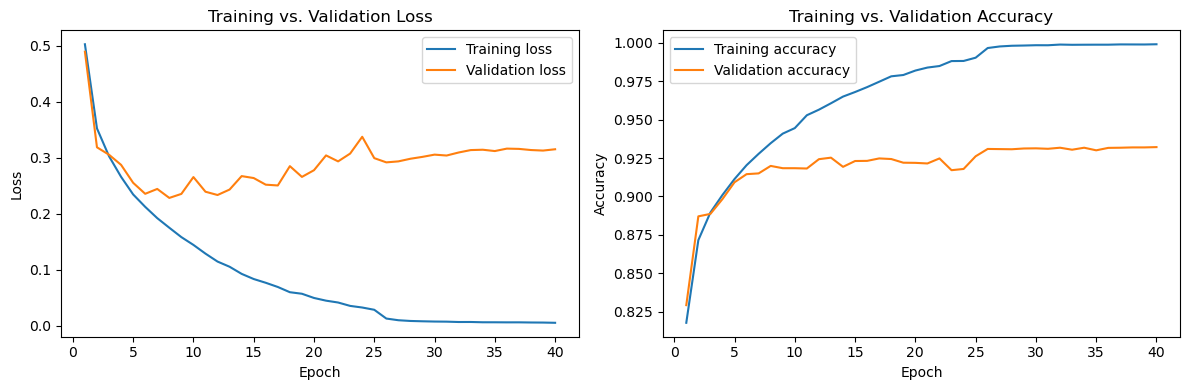

In [ ]:
#mostrar os resultados
epochs = range(1, n_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, trn_losses, label='Training loss')
ax1.plot(epochs, val_losses, label='Validation loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Training vs. Validation Loss')

ax2.plot(epochs, trn_accs, label='Training accuracy')
ax2.plot(epochs, val_accs, label='Validation accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.set_title('Training vs. Validation Accuracy')

plt.tight_layout()
plt.show()

### Test your model

In [ ]:
def Test(model, testload, criterion, device):
    N = len(testload)
    mean_loss = 0
    mean_acc  = 0
    for bx, data in enumerate(testload):
        loss, acc  = validate_batch(model, data, criterion, device)
        mean_loss += loss
        mean_acc  += acc

    mean_loss = mean_loss / N
    mean_acc  = mean_acc / N
    return(mean_loss, mean_acc)




In [ ]:
(mean, acc) = Test(model, testload, criterion, device)
print('Loss: {:.6f} Acc: {:.6f}'.format(mean,acc))

Loss: 0.314612 Acc: 0.931131


### Save and load your model

In [ ]:
# Save the tensors in the CPU format rather than in the GPU format to facilitate loading them later. It
# does not save the architecture of the model, so the class of the model is required to load it later.
# tenho que pegar os dicionarios dos resultados do modelo e colocar de volta o modelo na gpu
torch.save(model.to('cpu').state_dict(), 'FMNistCNN.pth')
#model.load_state_dict(torch.load('FMNistCNN.pth'))

#### Exercise: The model is overfitted. Play with datasets' sizes, network architecture, and hyperparameters to improve results without overfitting or underfitting.